# Importation des données


In [1]:
import pandas as pd

nom_fichier = "data_indian_ocean.feather"

df = pd.read_feather(nom_fichier)

df.columns
#


Index(['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog',
       'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)',
       'destination', 'information source', 'checked status', 'load type',
       'voyage number', 'origin->destination', 'at port', 'port stay type',
       'wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)'],
      dtype='object')

# Etude des trajectoires

In [2]:
import numpy as np 

# Compter les occurrences de chaque trajet
vc = df['origin->destination'].value_counts()

# Sélectionner les 10 trajets les plus fréquents
top10_trajets = vc.head(10).index.tolist()

print(top10_trajets)


['<NA>', '9aaf8f->9aaf8f', '4e0703->4e0703', 'c4e9ea->4e0703', '->9aaf8f', '9aaf8f->4e0703', '4e0703->9aaf8f', '2f737a->2f737a', '->4e0703', 'c4e9ea->c4e9ea']


In [3]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx

def plot_trajectory(df, origin_destination):
    # Filtrer le dataframe
    df_filt = df[df['origin->destination'] == origin_destination]

    if df_filt.empty:
        print("Aucune donnée pour ce origin->destination")
        return

    # Création de la géométrie
    geometry = [
        Point(lon, lat)
        for lon, lat in zip(df_filt['longitude'], df_filt['latitude'])
    ]

    gdf = gpd.GeoDataFrame(
        df_filt,
        geometry=geometry,
        crs="EPSG:4326"  # WGS84
    )

    # Reprojection pour contextily
    gdf = gdf.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))

    gdf.plot(
        ax=ax,
        color="red",
        markersize=5,
        alpha=0.7
    )

    # Fond de carte OpenStreetMap
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik
    )

    ax.set_title(f"Trajectoire : {origin_destination}")
    ax.set_axis_off()

    plt.show()


ModuleNotFoundError: No module named 'contextily'

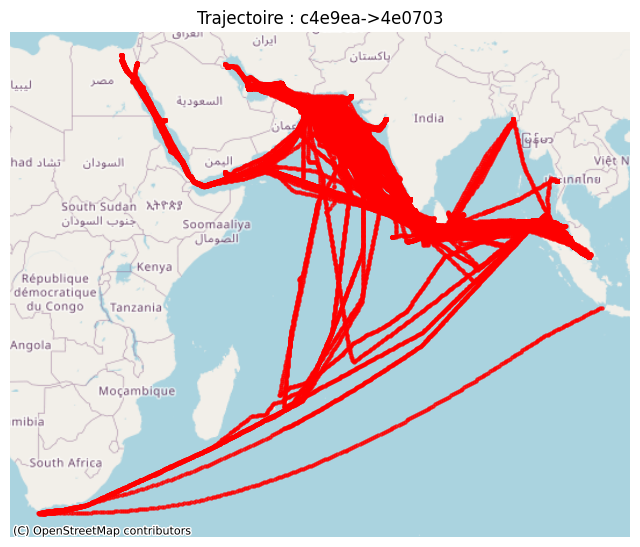

In [ ]:
plot_trajectory(df, 'c4e9ea->4e0703')


In [ ]:
import folium

def plot_trajectory_folium(df, origin_destination, output_file="trajectory.html"):
    # Filtrer le dataframe
    df_filt = df[df['origin->destination'] == origin_destination]

    if df_filt.empty:
        print("Aucune donnée pour ce origin->destination")
        return

    # Centre de la carte
    center_lat = df_filt['latitude'].mean()
    center_lon = df_filt['longitude'].mean()

    # Création de la carte
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=5,
        tiles="OpenStreetMap"
    )

    # Ajout des points
    for _, row in df_filt.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color="red",
            fill=True,
            fill_opacity=0.7,
            popup=f"""
                <b>Navire:</b> {row.get('name', 'N/A')}<br>
                <b>Timestamp:</b> {row['timestamp']}<br>
                <b>SOG:</b> {row.get('sog', 'N/A')}
            """
        ).add_to(m)

    # Sauvegarde
    m.save(output_file)
    print(f"Carte sauvegardée : {output_file}")


In [ ]:
"""plot_trajectory_folium(
    df,
    '86d05f->79a37c',
    output_file="lehavre_rotterdam.html"
)"""

'plot_trajectory_folium(\n    df,\n    \'86d05f->79a37c\',\n    output_file="lehavre_rotterdam.html"\n)'

# Découpage de la carte en carrés

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, box

# =========================
# PARAMÈTRES UTILISATEUR
# =========================
CELL_SIZE_METERS = 50000 

# =========================
# DONNÉES AIS
# =========================

# 1. Conversion en GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.longitude, df.latitude), 
    crs="EPSG:4326"
)

# 2. Projection UTM
gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())

# 3. Création de la grille
# On ajoute un ID unique à chaque carré de la grille dès sa création
xmin, ymin, xmax, ymax = gdf_utm.total_bounds
x_coords = np.arange(xmin, xmax + CELL_SIZE_METERS, CELL_SIZE_METERS)
y_coords = np.arange(ymin, ymax + CELL_SIZE_METERS, CELL_SIZE_METERS)

grid_cells = [
    box(x, y, x + CELL_SIZE_METERS, y + CELL_SIZE_METERS)
    for x in x_coords for y in y_coords
]

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=gdf_utm.crs)
grid['grid_id'] = range(len(grid)) # Création d'un ID propre (0, 1, 2...)

# =========================
# 4. Association points → carrés (MODIFIÉ)
# =========================

# On joint les points avec la grille. 
# Chaque point va récupérer les colonnes de la grille (dont 'grid_id')
gdf_with_grid = gpd.sjoin(
    gdf_utm, 
    grid[['grid_id', 'geometry']], 
    how="left", 
    predicate="within"
)

# On supprime la colonne temporaire 'index_right' créée par sjoin
if 'index_right' in gdf_with_grid.columns:
    gdf_with_grid = gdf_with_grid.drop(columns=['index_right'])

# =========================
# RÉSULTATS
# =========================

print("--- Points avec leur ID de carré ---")
# On repasse en WGS84 pour l'affichage final des points si besoin
points_final = gdf_with_grid.to_crs("EPSG:4326")
print(points_final[['latitude', 'longitude', 'grid_id']])

# Optionnel : calcul de densité toujours possible via grid_id
print("\n--- Densité par ID de carré ---")
print(points_final['grid_id'].value_counts())

--- Points avec leur ID de carré ---
           latitude  longitude  grid_id
0         25.031168  55.067681  12845.0
1         25.031168  55.067828  12845.0
2         25.031168  55.067757  12845.0
3         25.031168  55.067830  12845.0
4         25.031168  55.067745  12845.0
...             ...        ...      ...
13736053  11.464126  70.506199  19053.0
13736054  11.642743  70.351657  19053.0
13736055  11.817274  70.185509  18859.0
13736056  11.992234  70.012758  18859.0
13736057  12.187894  69.863625  18665.0

[13736058 rows x 3 columns]

--- Densité par ID de carré ---
grid_id
11677.0    790359
11482.0    355709
13430.0    283755
12845.0    239981
13626.0    174514
            ...  
31436.0         1
26556.0         1
20699.0         1
20894.0         1
21284.0         1
Name: count, Length: 17756, dtype: int64


# Vérification

In [ ]:
"""import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import ListedColormap
import numpy as np

# --- Définir la zone autour de l'Inde ---
india_bounds = {
    'lat_min': 5,
    'lat_max': 35,
    'lon_min': 65,
    'lon_max': 95
}

# --- Convertir gdf_with_grid en WGS84 avant filtrage ---
gdf_wgs = gdf_with_grid.to_crs("EPSG:4326")

# --- Filtrer les points autour de l'Inde ---
points_india = gdf_wgs[
    (gdf_wgs.geometry.y >= india_bounds['lat_min']) &
    (gdf_wgs.geometry.y <= india_bounds['lat_max']) &
    (gdf_wgs.geometry.x >= india_bounds['lon_min']) &
    (gdf_wgs.geometry.x <= india_bounds['lon_max'])
]

# --- Échantillon aléatoire de 100 000 points dans la zone ---
if len(points_india) > 100_000:
    sample_points = points_india.sample(n=100_000, random_state=42)
else:
    sample_points = points_india.copy()

# --- Créer un jeu de couleurs par grid_id ---
num_grids = sample_points['grid_id'].nunique()
colors = plt.cm.tab20(np.arange(num_grids) % 20)  # recycle si >20

# --- Tracé ---
fig, ax = plt.subplots(figsize=(14, 10))

sample_points.plot(
    ax=ax,
    column='grid_id',
    cmap=ListedColormap(colors),
    markersize=1,
    alpha=0.6,
    legend=False
)

# --- Ajouter un fond de carte OpenStreetMap ---
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=sample_points.crs.to_string(),
    zoom=5  # zoom adapté pour l'Inde
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Échantillon de 100 000 points AIS colorés selon leur carré")
plt.show()"""


'import matplotlib.pyplot as plt\nimport contextily as ctx\nfrom matplotlib.colors import ListedColormap\nimport numpy as np\n\n# --- Définir la zone autour de l\'Inde ---\nindia_bounds = {\n    \'lat_min\': 5,\n    \'lat_max\': 35,\n    \'lon_min\': 65,\n    \'lon_max\': 95\n}\n\n# --- Convertir gdf_with_grid en WGS84 avant filtrage ---\ngdf_wgs = gdf_with_grid.to_crs("EPSG:4326")\n\n# --- Filtrer les points autour de l\'Inde ---\npoints_india = gdf_wgs[\n    (gdf_wgs.geometry.y >= india_bounds[\'lat_min\']) &\n    (gdf_wgs.geometry.y <= india_bounds[\'lat_max\']) &\n    (gdf_wgs.geometry.x >= india_bounds[\'lon_min\']) &\n    (gdf_wgs.geometry.x <= india_bounds[\'lon_max\'])\n]\n\n# --- Échantillon aléatoire de 100 000 points dans la zone ---\nif len(points_india) > 100_000:\n    sample_points = points_india.sample(n=100_000, random_state=42)\nelse:\n    sample_points = points_india.copy()\n\n# --- Créer un jeu de couleurs par grid_id ---\nnum_grids = sample_points[\'grid_id\'].nuniq

# Ajout de l'id des carrés à la grille 

In [ ]:
df_with_grid = df.copy()
df_with_grid['grid_id'] = gdf_with_grid['grid_id'].values

df_with_grid['grid_id']

0           12845.0
1           12845.0
2           12845.0
3           12845.0
4           12845.0
             ...   
13736053    19053.0
13736054    19053.0
13736055    18859.0
13736056    18859.0
13736057    18665.0
Name: grid_id, Length: 13736058, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

def plot_dense_grid_matplotlib(gdf_with_grid, quantile=0.9, output_file=None):
    """
    Affiche les carrés contenant le plus de points AIS sur un fond de carte.
    Les carrés sont tracés avec contours et semi-transparence.

    Paramètres :
    - gdf_with_grid : GeoDataFrame avec 'grid_id' et géométrie des carrés (en UTM)
    - quantile : seuil pour filtrer les carrés denses (0.9 = top 10%)
    - output_file : si fourni, sauvegarde la figure en PNG
    """
    
    # 1️⃣ Calcul de la densité de points par carré
    counts = gdf_with_grid['grid_id'].value_counts()
    threshold = counts.quantile(quantile)
    dense_ids = counts[counts >= threshold].index

    # 2️⃣ Sélection des carrés denses
    dense_grid = (
        gdf_with_grid[['grid_id', 'geometry']]
        .drop_duplicates(subset='grid_id')
        .query('grid_id in @dense_ids')
    )

    # 3️⃣ Reprojection en Web Mercator pour contexte basemap
    dense_grid_merc = dense_grid.to_crs(epsg=3857)

    # 4️⃣ Plot
    fig, ax = plt.subplots(figsize=(12, 12))

    # Tracer les carrés avec contours noirs et face color semi-transparent
    dense_grid_merc.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
    dense_grid_merc.plot(ax=ax, facecolor='red', alpha=0.3)

    # Fond de carte
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Zoom automatique sur la zone dense
    xmin, ymin, xmax, ymax = dense_grid_merc.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f"Carrés contenant le top {int((1-quantile)*100)}% des points", fontsize=14)
    ax.set_axis_off()

    # 5️⃣ Sauvegarde optionnelle
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', dpi=300)
        print(f"Figure sauvegardée : {output_file}")

    plt.show()


/tmp/ipykernel_199695/4051212740.py:34: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  dense_grid_merc.boundary.plot(ax=ax, edgecolor='black', linewidth=1)


Figure sauvegardée : dense_grid.png


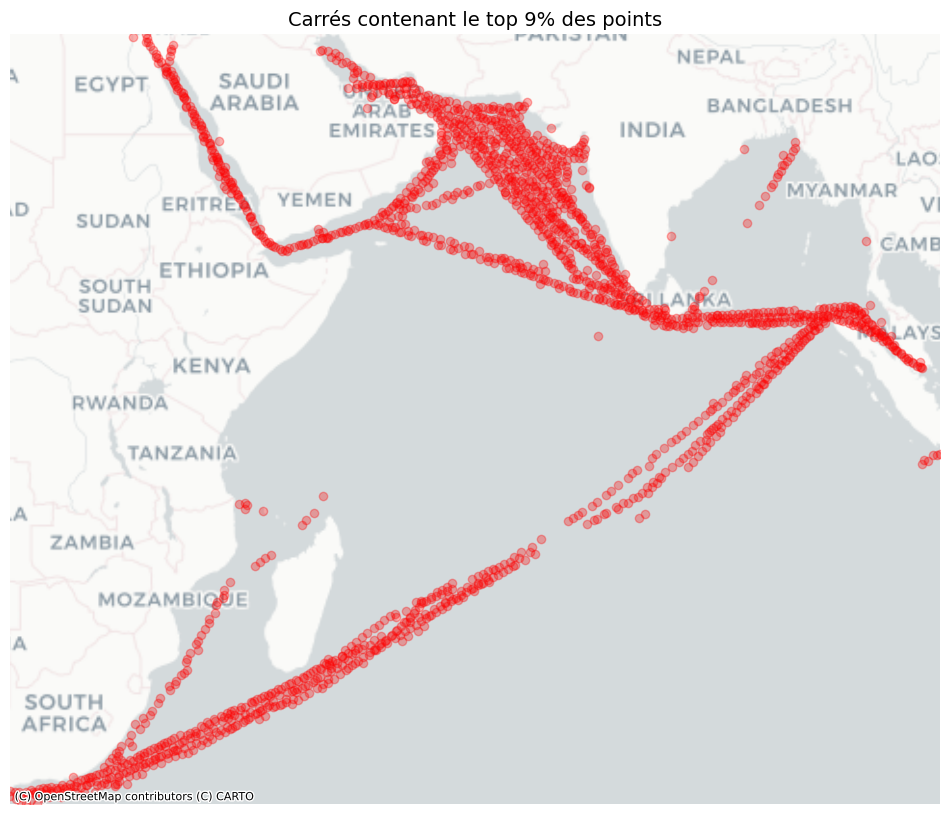

In [ ]:
# Afficher les carrés du top 10% en densité
plot_dense_grid_matplotlib(gdf_with_grid, quantile=0.90, output_file="dense_grid.png")


# Cap & position 

In [ ]:
import numpy as np
import pandas as pd

def add_cap_vectorized(df):
    """
    Version vectorisée pour ajouter les vecteurs suivant et précédent.
    """

    df = df.copy()

    # vecteur suivant
    dx_next = df['longitude'].shift(-1) - df['longitude']
    dy_next = df['latitude'].shift(-1) - df['latitude']

    # vecteur précédent
    dx_prev = df['longitude'] - df['longitude'].shift(1)
    dy_prev = df['latitude'] - df['latitude'].shift(1)

    # fonction pour calculer norme et angle
    def compute_vector(dx, dy):
        norme = np.sqrt(dx**2 + dy**2)
        angle = np.degrees(np.arctan2(dy, dx)) % 360
        return (norme, angle)

    # vectorisation avec apply sur les colonnes
    df['vec_next'] = [compute_vector(dx, dy) if not np.isnan(dx) else None
                      for dx, dy in zip(dx_next, dy_next)]
    df['vec_prev'] = [compute_vector(dx, dy) if not np.isnan(dx) else None
                      for dx, dy in zip(dx_prev, dy_prev)]

    # gérer les frontières de chaque voyage
    df['vec_next'] = df.groupby('voyage number')['vec_next'].apply(lambda x: x[:-1].tolist() + [None])
    df['vec_prev'] = df.groupby('voyage number')['vec_prev'].apply(lambda x: [None] + x[1:].tolist())

    return df

#add_cap_vectorized(gdf_with_grid)
gdf_with_grid = add_cap_vectorized(gdf_with_grid)


In [ ]:
# Comptage du nombre de points par carré
counts = gdf_with_grid['grid_id'].value_counts()

# Seuil pour top 1%
threshold = counts.quantile(0.9)

# IDs des carrés qui sont dans le top 1%
top1_percent_ids = counts[counts >= threshold].index.tolist()

# Pour commencer, on prend le carré le plus peuplé
selected_grid_id = top1_percent_ids[0]

print(f"Carré choisi (top 1%) : {selected_grid_id} avec {counts[selected_grid_id]} points")


Carré choisi (top 1%) : 11677.0 avec 790359 points


In [ ]:
points_top_square = gdf_with_grid[gdf_with_grid['grid_id'] == selected_grid_id]
print(f"Nombre de vecteurs disponibles dans le carré {selected_grid_id} : {len(points_top_square['vec_next'].dropna())}")



Nombre de vecteurs disponibles dans le carré 11677.0 : 0


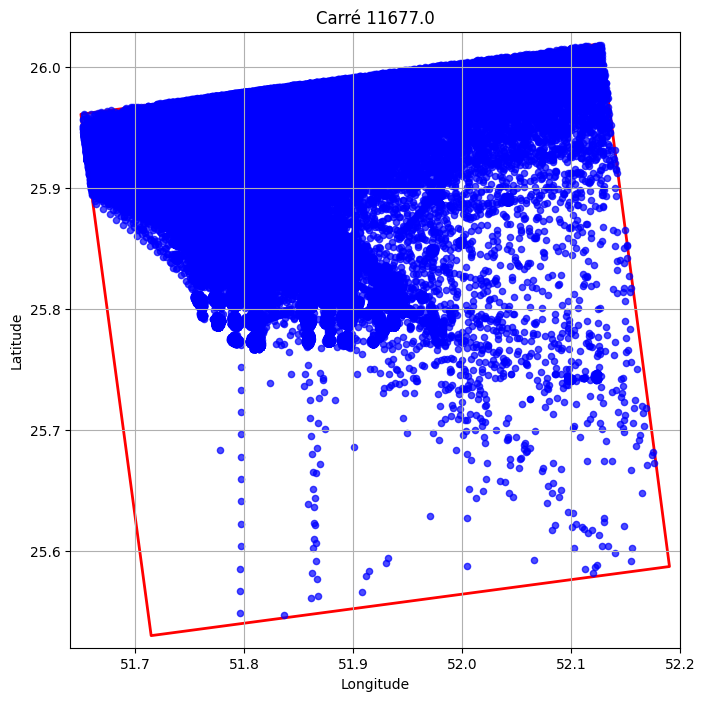

Carte sauvegardée dans le fichier : carte_carre_11677.0.png


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Carré sélectionné
# -----------------------------
selected_square = grid[grid['grid_id'] == selected_grid_id].geometry.values[0]  # shapely Polygon

# Conversion en WGS84 pour Matplotlib si nécessaire
square_wgs84 = gpd.GeoSeries([selected_square], crs=gdf_utm.crs).to_crs("EPSG:4326")

# -----------------------------
# Points dans le carré
# -----------------------------
points_wgs84 = points_top_square.to_crs("EPSG:4326")

# -----------------------------
# Préparer la figure
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# -----------------------------
# Ajouter le carré
# -----------------------------
square_wgs84.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
ax.set_title(f"Carré {selected_grid_id}")

# -----------------------------
# Ajouter les points
# -----------------------------
points_wgs84.plot(ax=ax, color='blue', markersize=20, alpha=0.7)

# -----------------------------
# Ajuster l'affichage
# -----------------------------
# Limites basées sur le carré pour zoomer
minx, miny, maxx, maxy = square_wgs84.total_bounds
ax.set_xlim(minx - 0.01, maxx + 0.01)
ax.set_ylim(miny - 0.01, maxy + 0.01)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

# -----------------------------
# Sauvegarder la figure
# -----------------------------
output_file = f"carte_carre_{selected_grid_id}.png"
plt.savefig(output_file, dpi=300)
plt.show()
print(f"Carte sauvegardée dans le fichier : {output_file}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# On récupère les angles (deuxième élément du vecteur)
angles = points_top_square['vec_next'].dropna().apply(lambda x: x[1])  # x[1] = angle en degrés

# Conversion en radians pour le plot polaire
angles_rad = np.radians(angles)

# Création du plot polar
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

# Histogramme polaire
n, bins, patches = ax.hist(angles_rad, bins=36, density=True, color='blue', alpha=0.7)

# Paramètres visuels
ax.set_title(f"Rose des vents - Carré {selected_grid_id}", va='bottom', fontsize=14)
ax.set_theta_zero_location('N')  # 0° en haut (Nord)
ax.set_theta_direction(-1)       # sens horaire

plt.show()


/opt/python/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (0,)

<Figure size 800x800 with 1 Axes>